## Objetivo

O objetivo da análise exploratória de dados (EDA) é compreender melhor o conjunto de dados, investigando sua estrutura, distribuição e possíveis padrões. Além disso, busca-se identificar relações entre variáveis, detectar outliers e avaliar quais características podem impactar positiva ou negativamente o desempenho dos modelos de predição para o target **SalePrice** (o preço final de um imóvel dado um conjunto de características).

In [1]:
import sys 
import os 

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from src.data_cleaning import data_cleaning, ordinal_variables
from src.data_collection import data_collection
from scipy.stats import f_oneway
import statsmodels.api as sm

In [3]:
data_collection()

Descompactado: house-prices-advanced-regression-techniques.zip


In [4]:
df = pd.read_csv('../data/raw/train.csv', sep=',')

In [5]:
df = df.drop('Id', axis=1)

In [6]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## 1. Distribuição do target SalePrice

Como primeira etapa, identificaremos o comportamento da distribuição dos dados do target 'SalePrice'. Um dado $x_i$ é um outlier se:

$$x_i < Q_1 - 1.5 \times \text{IQR}$$

ou 

$$x_i > Q_3 + 1.5 \times \text{IQR}$$

onde $\text{IQR}$ é a distância inter-quartil: 

$$\text{IQR} = Q_3 - Q_1$$

In [8]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < limite_inferior) | (df["SalePrice"] > limite_superior)]

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", Q3 - Q1)

outliers

Q1:  129975.0
Q3:  214000.0
IQR:  84025.0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,60,RL,85.0,11924,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,345000
53,20,RL,68.0,50271,Pave,NaN,IR1,Low,AllPub,Inside,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,385000
58,60,RL,66.0,13682,Pave,NaN,IR2,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,438780
112,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,383970
151,20,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2008,New,Partial,372402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,50,RL,NaN,14100,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,381000
1353,50,RL,56.0,14720,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,410000
1373,20,RL,NaN,11400,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2007,WD,Normal,466500
1388,20,RL,42.0,14892,Pave,NaN,IR1,HLS,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,10,2009,WD,Normal,377500


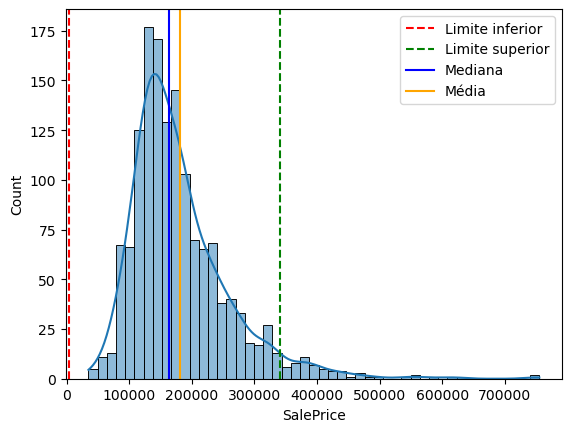

In [9]:
sns.histplot(data=df, x='SalePrice', kde=True)

plt.axvline(limite_inferior, color='red', linestyle='--', label='Limite inferior')
plt.axvline(limite_superior, color='green', linestyle='--', label='Limite superior')
plt.axvline(df['SalePrice'].median(), color='blue', linestyle='-', label='Mediana')
plt.axvline(df['SalePrice'].mean(), color='orange', linestyle='-', label='Média')

plt.legend()
plt.show()

<Axes: >

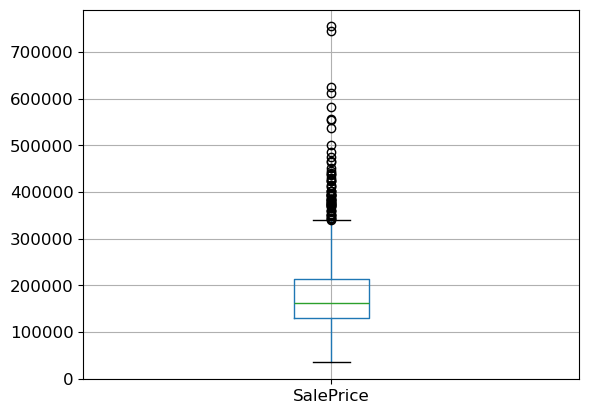

In [10]:
df.boxplot(column='SalePrice', fontsize=12, grid=True)

Como observado tanto no histograma quanto no boxplot, a variável alvo **SalePrice** apresenta uma distribuição assimétrica à direita (right-skewed), caracterizada por uma cauda mais longa em direção aos valores mais altos. Isso indica que a maioria dos imóveis possui preços concetrados em faixas menores, enquanto alguns poucos apresentam valores significativamente elevados. 

Para reduzir essa assimetria e aproximar a distribuição de uma forma mais próxima da normal, é comum aplicar uma transformação logarítmica na variável alvo. Essa transformação comprime os valores mais altos e tende a tornar a distribuição mais simétrica, o que pode melhorar o desempenho e a estabilidade dos modelos de regressão que serão usados.

Assim, em feature_engineering, transformaremos o target SalePrice fazendo:

$$
    SalePrice = log(SalePrice)
$$

<Axes: xlabel='SalePrice', ylabel='Count'>

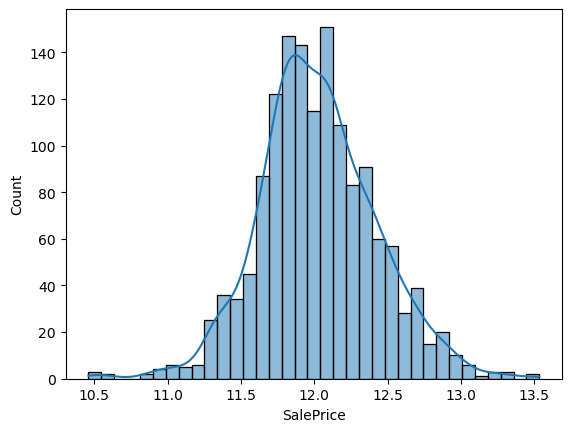

In [11]:
sns.histplot(np.log1p(df['SalePrice']), kde=True)

## 2. Valores ausentes

Vamos analisar o comportamento dos dados ausentes no dataset. Para isso, vamos calcular a porcentagem de dados ausentes em cada uma das colunas.

O primeiro passo é identificar quais colunas possuem dados ausentes:

In [12]:
missing_cols = df.columns[df.isna().sum() > 0]

missing_cols

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

E então calculamos a porcentagem relativa à aquela coluna:

In [13]:
missing_percent = (df[missing_cols].isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_percent

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

Ao observar o README.md em data, concluímos que a ausência de algumas variáveis podem ser explicadas pela ausência de uma determinada característica na casa. Por exemplo, casas sem dados de PoolQC (qualidade da piscina) não possuem piscina, o mesmo para FireplaceQu (qualidade da lareira), entre outras. Assim, essas variáveis serão tratadas em "2_feature_engineering.ipynb".

| Variável | Como tratar missing values |
|----------|----------------------------|
| PoolQC | A grande quanidade de dados ausentes representa casas que não possuem piscina, substituir por "None"|
| MiscFeature | A residência não possui características não explicadas pelas outras variáveis, substituir por "None"|
| Alley | A residência não possui acesso a beco, substituir por "None" | 
| Fence | A residência não possui cercas, substituir por "None" |
| MasVnrType | A residência não possui revestimento de alvenaria, substituir por "None" | 
| FireplaceQu | A residência não possui lareira, substituir por "None" |
| LotFrontage | Não há informação do comprimento da rua conectada ao lote; pode ser estimado pela mediana do bairro (Neighborhood) |
| GarageType | A residência não possui garagem, substituir por "None"|
| GarageYrBlt | Não há informação sobre data de construção da garagem, substituir pelo mesmo ano de criação da casa (YearBuilt)| 
| GarageFinish | A residência não possui garagem, substituir por "None"| 
|GarageQual| A residência não possui garagem, substituir por "None"| 
|BsmtExposure| A residência não possui porão, substituir por "None"|
|BsmtFinType1| A residência não possui acabamento no porão, substituir por "None"|
|BsmtFinType2| A residência não possui segundo tipo de acabamento no porão, substituir por "None"|
|BsmtQual| A residência não possui porão, substituir por "None"|
|BsmtCond | A residência não possui porão, substituir por "None"| 
| BsmntFinType1 | A residência não possui acabamento principal no porão, substituir por "None"|
|MasVnrArea| Se MasVnrType = None, então MasVnrArea = 0|
| Electrical | Poucos valores faltantes, substituir pela moda| 


## 3. Correlação entre SalePrice e variáveis numéricas 

Agora, calcularemos a correlação linear entre "SalePrice" e as variáveis numéricas. Matematicamente, o pandas calcula a correlação linear de Pearson, que mede o quanto duas variáveis têm relação linear.

$$
r = \frac{\text{Cov}(X, Y)}{\sigma_{X}\sigma_{Y}}
$$

onde:

- $\text{Cov}(X,Y)$ é a covariância entre as variáveis;
- $\sigma_{X}, \ \sigma_{Y}$ os desvios padrão.

O valor de $r$ varia entre $-1$ e $1$, onde:

|Valor| Interpretação|
| --- | -------------- |
|$\ 1$| correlação linear positiva perfeita|
|$\ 0$| nenhuma corerlação linear| 
|$-1$| correção linear negativa perfeita|

In [14]:
df["SalePrice_log"] = np.log(df["SalePrice"])

corr = df.corr(numeric_only=True)["SalePrice_log"].sort_values(ascending=False)

corr

SalePrice_log    1.000000
SalePrice        0.948374
OverallQual      0.817184
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489449
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355878
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209044
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057329
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

As variáveis 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF' possuem alta correlação linear com o target 'SalePrice_log'.

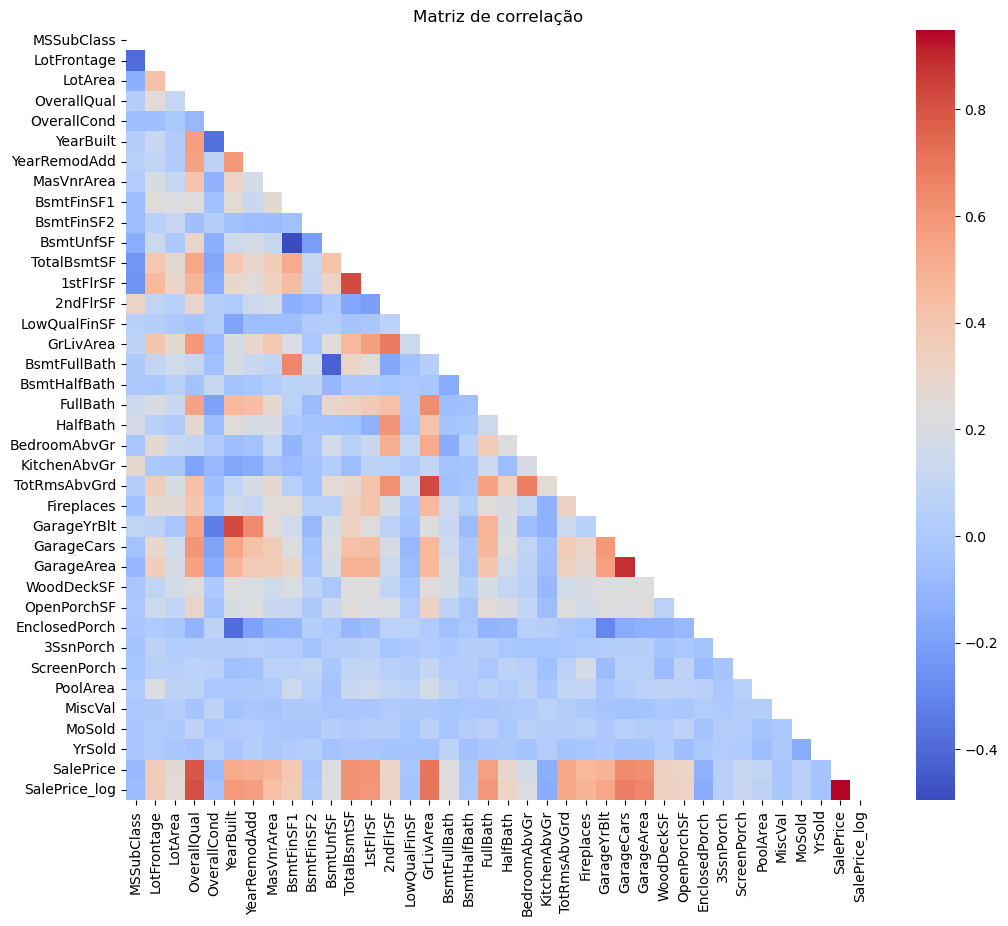

In [15]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlação")
plt.show()

## 4. Identificando multicolinearidade

A multicolinearidade ocorre quando duas ou mais variáveis preditoras de um modelo apresentam forte correlação entre si. Assim, uma variável pode ser perfeitamente (ou aproximadamente) explicada como combinação linear de outras variáveis. Em uma regressão linear múltipla, estimamos coeficientes no modelo, na forma matricial:

$$
\hat{\beta} = (X^{T}X)^{-1}X^{T}y
$$

Quando há multicolinearidade, $X_i$ e $X_j$ são quase paralelos:

$$
X_j \approx cX_i
$$

gerando grandes variações em $\hat{\beta}$ para pequenas mudanças em $X_j$ e $X_i$, o que reduz o desempenho do modelo. No nosso dataset, existem algumas colunas que são candidatas a serem exemplo de multicolinearidade pois possuem a mesma interpretação. Por exemplo, 'GarageArea' e 'GarageCars' são maneiras de medir o tamanho de uma garagem, mudando somente a unidade de medida. Para avaliarmos multicolinearidade entre as variáveis numéricas do dataset, medimos a correlação entre elas:

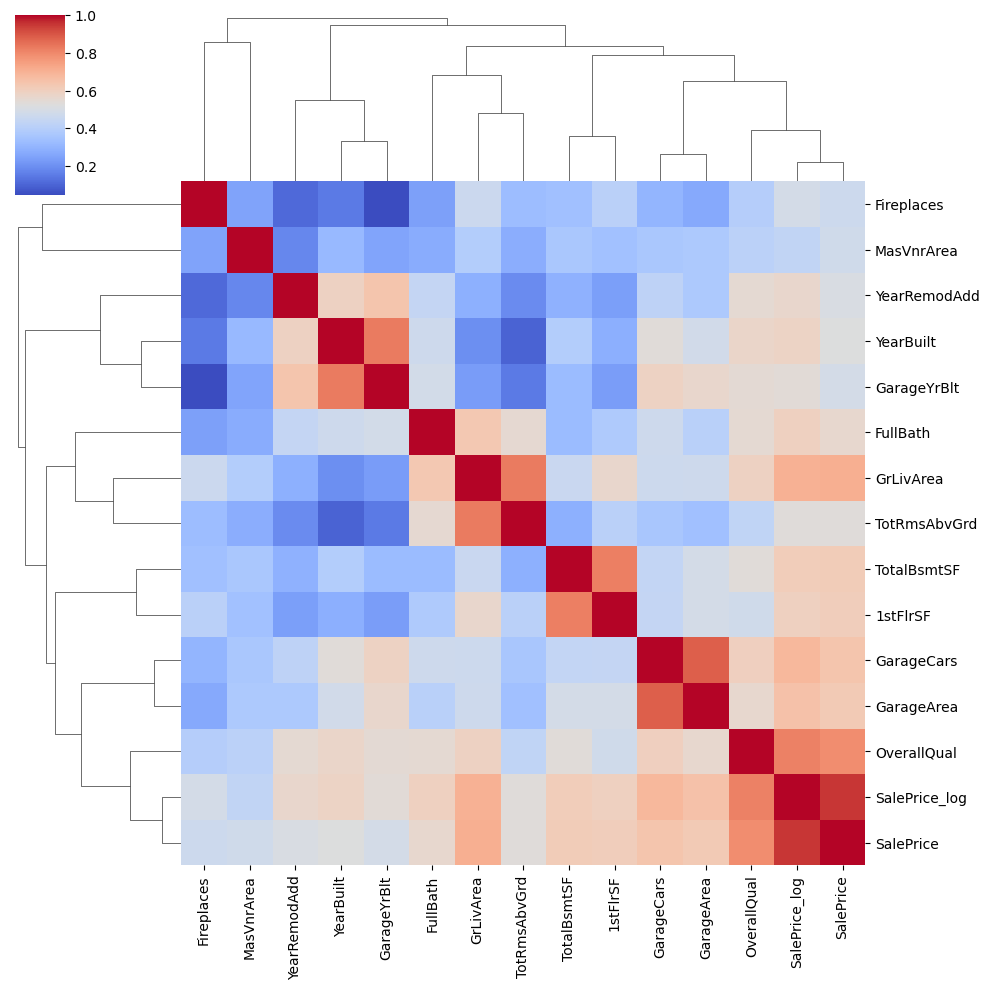

In [16]:
corr = df.corr(numeric_only=True)["SalePrice_log"].abs().sort_values(ascending=False)
top = corr[:15].index

sns.clustermap(df[top].corr(), cmap="coolwarm")

In [17]:
corr = df.corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

threshold = 0.8

collinear_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > threshold
]

collinear_pairs

[('1stFlrSF', 'TotalBsmtSF', np.float64(0.8195299750050339)),
 ('TotRmsAbvGrd', 'GrLivArea', np.float64(0.8254893743088425)),
 ('GarageYrBlt', 'YearBuilt', np.float64(0.8256674841743408)),
 ('GarageArea', 'GarageCars', np.float64(0.882475414281462)),
 ('SalePrice_log', 'OverallQual', np.float64(0.8171844179216803)),
 ('SalePrice_log', 'SalePrice', np.float64(0.9483737306090587))]

### Interpretação:

- A coluna '1stFlrSF' é a área do primeiro andar, enquanto 'TotalBsmtSF' a área do porão. Essas duas variáveis são correlacionadas porque casas maiores tendem a ter porões maiores, não sendo necessário remoção dessas colunas para avaliar o modelo;

- A coluna 'TotRmsAbvGrd' representa o número de quartos, enquanto 'GrLivArea' a área habitável. Como 'GrLivArea' costuma ser mais informativa, removeremos 'TotRmsAbvGrd';

- A coluna 'GarageYrBlt' repreenta o ano em que a garagem foi construída, enquanto 'YearBuilt' o ano em que a casa foi construída. Normalmente a garagem é construída junto com a casa, então removeremos 'GarageYrBlt';

- A coluna 'GarageCars' representa o número de carros e 'GarageArea' a área da garagem, como elas medem a mesma coisa e 'GarageCars' é mais interpretável, removeremos 'GarageArea'.

## 5. Análise da relação entre variáveis numéricas e o target

### 5.1 Overall Quality

Dentre as variáveis numéricas, Overall Quality possui a maior correlação com o target. Essa variável avalia o material e acabamento geral da casa em uma escala de 1 (muito ruim) e 10 (excelente). Logicamente, é de se esperar que quanto melhor o acabamento da casa, maior o seu preço. 

Para analisar se isso é comprovado pelos dados:

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

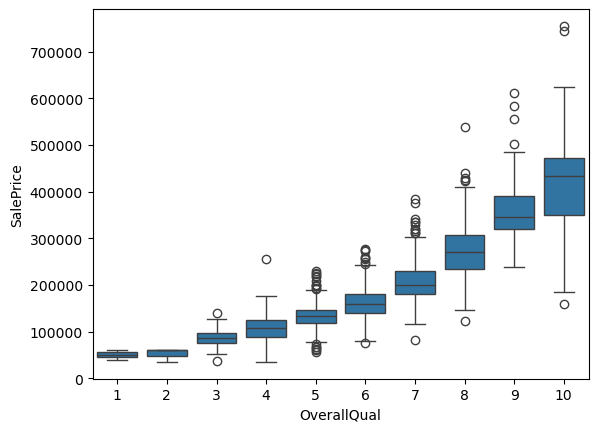

In [18]:
sns.boxplot(data=df, x='OverallQual', y='SalePrice')

A teoria e correlação podem ser comprovadas pelo boxplot acima. Quanto a outliers, não há nenhum outliers que aparente ser prejudicial para análise, com exceção da casa muito cara com OverralQual 4.

### 5.2 Grade Living Area 

A segunda variável numérica com maior correlação linear com o target SalePrice é a área habitável do terreno (GrLivArea). O que também faz sentido pois, quanto maior a casa, maior o preço. 

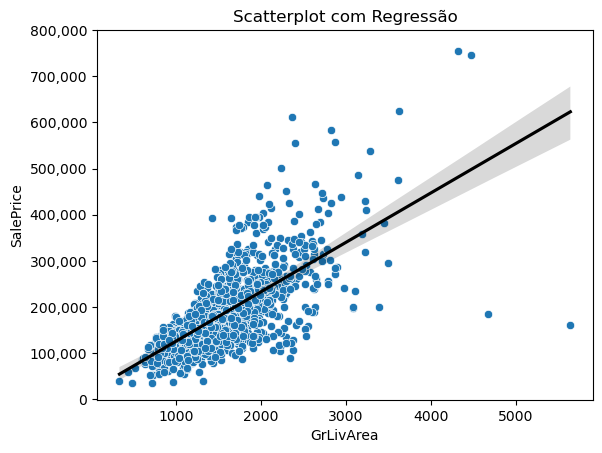

In [19]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
sns.regplot(data=df, x='GrLivArea', y='SalePrice', scatter=False, color='black')

plt.yticks(np.arange(0, 800001, 100000))
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Scatterplot com Regressão")

plt.show()

A relação linear se comprova. Existem dois outliers que chamam muita atenção: duas casas com GrLivArea muito grandes e valores de venda muito baixos. Mas o que pode explicar isso? Para responder a pergunta, vamos identificar quais são as duas casas:

In [20]:
df_sorted = df.sort_values(by='GrLivArea', ascending=False)

top1 = df_sorted.iloc[0]

print("Casa com maior GrLivArea: ", top1)
print("OverallQual da casa top1: ", top1['OverallQual'])

Casa com maior GrLivArea:  MSSubClass              60
MSZoning                RL
LotFrontage          313.0
LotArea              63887
Street                Pave
                   ...    
YrSold                2008
SaleType               New
SaleCondition      Partial
SalePrice           160000
SalePrice_log    11.982929
Name: 1298, Length: 81, dtype: object
OverallQual da casa top1:  10


In [21]:
top2 = df_sorted.iloc[1]

print("Casa com segundo maior GrLivArea: ", top2)
print("OverallQual da casa top2: ", top2['OverallQual'])

Casa com segundo maior GrLivArea:  MSSubClass              60
MSZoning                RL
LotFrontage          130.0
LotArea              40094
Street                Pave
                   ...    
YrSold                2007
SaleType               New
SaleCondition      Partial
SalePrice           184750
SalePrice_log    12.126759
Name: 523, Length: 81, dtype: object
OverallQual da casa top2:  10


As duas casas além de serem grandes, possuem OverallQua máximo. Será que são pertencetes a um bairro mais barato? Se sim, isso pode explicar a discrepância, caso contrário, são outliers a serem removidos.

In [22]:
bairro_top1 = top1['Neighborhood']
media_bairro_top1 = df[df['Neighborhood'] == bairro_top1]['SalePrice'].mean()
diferenca_top1 = top1['SalePrice'] - media_bairro_top1
percentual_top1 = (diferenca_top1 / media_bairro_top1) * 100

print(f"Bairro: {bairro_top1}")
print(f"Preço da casa top1: {top1['SalePrice']}")
print(f"Média do bairro: {media_bairro_top1}")
print(f"Diferença: {diferenca_top1:.2f}")
print(f"Acima da média: {percentual_top1:.2f}%")


Bairro: Edwards
Preço da casa top1: 160000
Média do bairro: 128219.7
Diferença: 31780.30
Acima da média: 24.79%


In [23]:
bairro_top2 = top2['Neighborhood']
media_bairro_top2 = df[df['Neighborhood'] == bairro_top2]['SalePrice'].mean()
diferenca_top2 = top2['SalePrice'] - media_bairro_top2
percentual_top2 = (diferenca_top2 / media_bairro_top2) * 100

print(f"Bairro: {bairro_top2}")
print(f"Preço da casa top2: {top2['SalePrice']}")
print(f"Média do bairro: {media_bairro_top2}")
print(f"Diferença: {diferenca_top2:.2f}")
print(f"Acima da média: {percentual_top2:.2f}%")

Bairro: Edwards
Preço da casa top2: 184750
Média do bairro: 128219.7
Diferença: 56530.30
Acima da média: 44.09%


### 5.3 Garage Cars

A próxima variável com maior correlação com o target SalePrice é GarageCars, que é uma unidade de medida do tamanho da garagem em termos da quantidade de carros que ela suporta. Como visto anteriormente, ela possui uma grande correlação com a variável GarageArea. Agora, iremos analisar como GarageCars se relaciona com SalePrice:

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

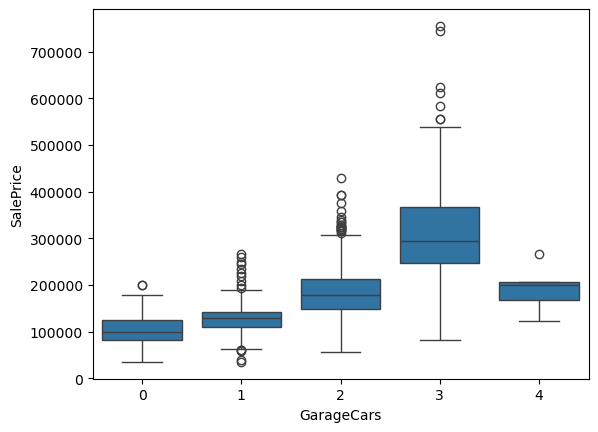

In [24]:
sns.boxplot(data=df, x='GarageCars', y='SalePrice')

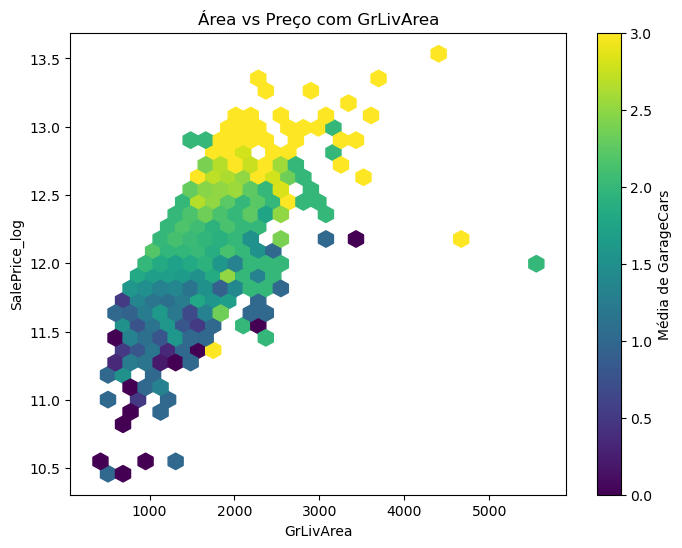

In [25]:
plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df['GrLivArea'],
    df['SalePrice_log'],
    C=df['GarageCars'],      # variável extra
    reduce_C_function=np.mean,  # média de banheiros
    gridsize=30
)

plt.colorbar(label='Média de GarageCars')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice_log')
plt.title('Área vs Preço com GrLivArea')

plt.show()

Casas com espaço para 3 carros na garagem tendem a ser mais caras do que casas com 4 carros na garagem, mesmo para o mesmo GrLivArea.

### 5.4 TotalBsmtSF 

Agora, analisaremos a relação entre a área total do porão (TotalBsmtSF) e o target SalePrices. Como visto anteriormente, TotalBsmtSF possui alta correlação com 1stFlrSF.

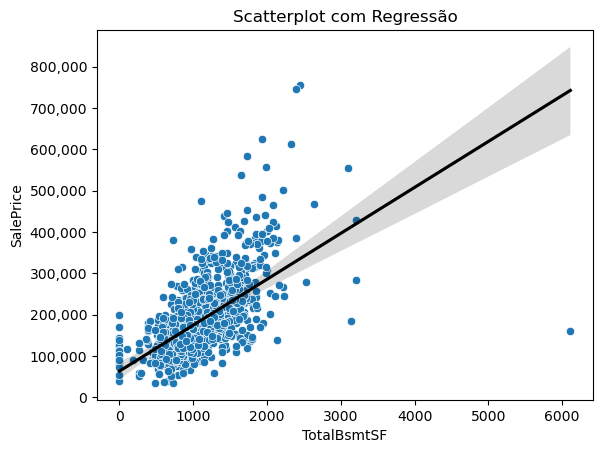

In [26]:
sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice')
sns.regplot(data=df, x='TotalBsmtSF', y='SalePrice', scatter=False, color='black')

plt.yticks(np.arange(0, 800001, 100000))
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.xlabel("TotalBsmtSF")
plt.ylabel("SalePrice")
plt.title("Scatterplot com Regressão")

plt.show()

Existe uma casa com o porão muito grande e valor de venda muito baixo, será que isso pode ser explicado pela qualidade do porão?

In [27]:
df.loc[df['TotalBsmtSF'].idxmax(), ['TotalBsmtSF', 'SalePrice', 'GrLivArea', 'OverallQual', 'BsmtCond', 'Neighborhood']]

TotalBsmtSF        6110
SalePrice        160000
GrLivArea          5642
OverallQual          10
BsmtCond             TA
Neighborhood    Edwards
Name: 1298, dtype: object

In [28]:
df.groupby('BsmtCond')['SalePrice'].mean().sort_values()

BsmtCond
Po     64000.000000
Fa    121809.533333
TA    183632.620900
Gd    213599.907692
Name: SalePrice, dtype: float64

### 5.5 FullBath

Agora, avaliaremos a quantidade de banheiros completos acima do nível do solo (FullBath). Avaliaremos também se FullBath realmente influencia o preço de SalePrice, uma vez que quanto maior a quantidade de banheiros, maior a GrLivArea (que possui uma correlação com SalePrice maior que FullBath).

<Axes: xlabel='FullBath', ylabel='SalePrice'>

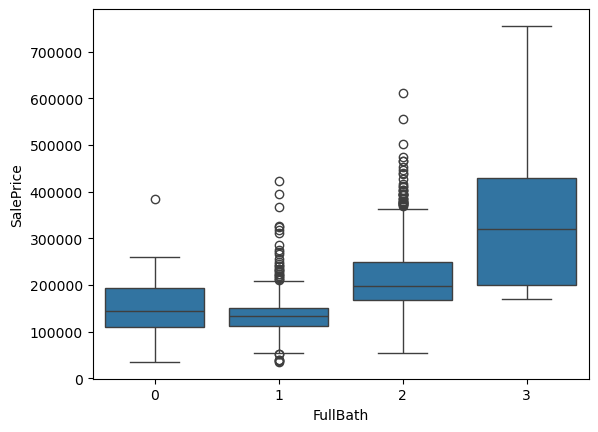

In [29]:
sns.boxplot(data=df, x='FullBath', y='SalePrice')

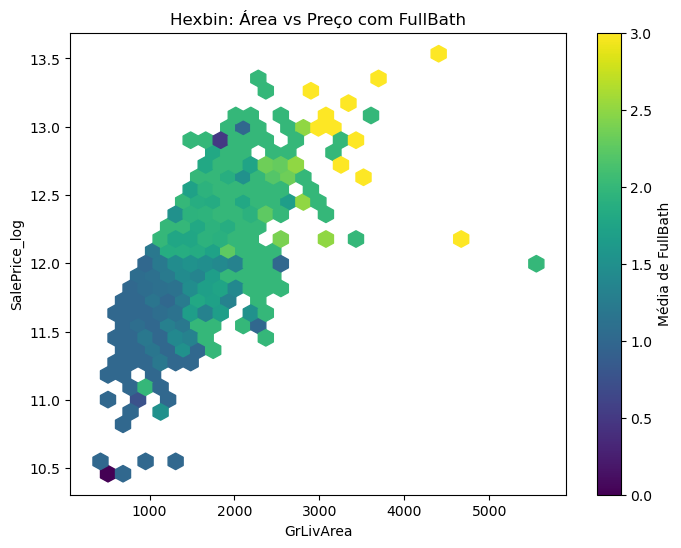

In [30]:
plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df['GrLivArea'],
    df['SalePrice_log'],
    C=df['FullBath'],      # variável extra
    reduce_C_function=np.mean,  # média de banheiros
    gridsize=30
)

plt.colorbar(label='Média de FullBath')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice_log')
plt.title('Hexbin: Área vs Preço com FullBath')

plt.show()

In [31]:
df[['GrLivArea', 'FullBath']].corr()

,GrLivArea,FullBath
GrLivArea,1.000000,0.630012
FullBath,0.630012,1.000000


Existe uma correlação forte entre FullBath e GrLivArea, afinal, quanto maior a quantidade de banheiros, maior a área habitável. A diferença de preço para casas de mesmo tamanho no salto de 1 para 2 banheiros é alta, enquanto casas com 3 banheiros estão mais presentes em casas grandes, que já são mais caras. 

Outro ponto é: existente muitas variáveis para descrever o banheiro e muitas delas possuem pouca correlação linear com o target. Assim, talvez seja interessante mesclarmos todas essas variáveis em uma única variável:

$$
    \text{TotalBathrooms} = \text{FullBath} + \frac{1}{2}\times\text{HalfBath} + \text{BsmtFullBath} + \frac{1}{2}\times\text{BsmtHalfBath}
$$

In [32]:
df[['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']].isnull().sum()

FullBath        0
HalfBath        0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

In [33]:
df['TotalBathrooms'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)

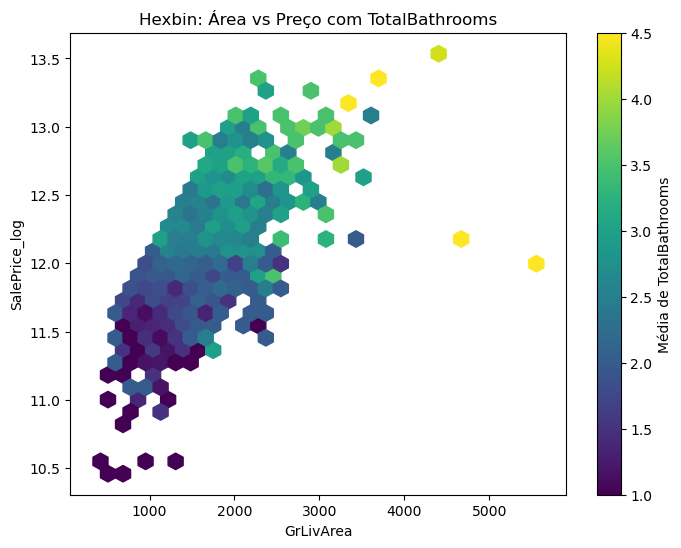

In [34]:
plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df['GrLivArea'],
    df['SalePrice_log'],
    C=df['TotalBathrooms'],      # variável extra
    reduce_C_function=np.mean,  # média de banheiros
    gridsize=30
)

plt.colorbar(label='Média de TotalBathrooms')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice_log')
plt.title('Hexbin: Área vs Preço com TotalBathrooms')

plt.show()

In [35]:
df[['TotalBathrooms', 'SalePrice']].corr()

,TotalBathrooms,SalePrice
TotalBathrooms,1.000000,0.631731
SalePrice,0.631731,1.000000


Conclusão: o desenvolvimento da variável TotalBathrooms reduz a complexidade do modelo pois vamos de 4 variáveis para descrever o banheiro para apenas 1 e, além disso, aumenta consideravelmente a correlação entre os banheiros e o target SalePrice. Iremos adotar essa abordagem em 2_feature_engineering.

Ainda, é possível desenvolver uma variável:

$$
    \text{TotalArea} = \text{GrLivArea} + \text{TotalBathrooms} 
$$



In [36]:
df['TotalArea'] = (
    df['GrLivArea'] 
    + df['TotalBathrooms']
)

In [37]:
df[['TotalArea', 'SalePrice']].corr()

,TotalArea,SalePrice
TotalArea,1.000000,0.708938
SalePrice,0.708938,1.000000


A correlação de TotalArea com SalePrice é ainda maior que a de GrLivArea com SalePrice, reduzindo mais uma vez a quantidade de variáveis.

### 5.5 YearBuilt

Agora, investigaremos a variável que representa o ano de construção da casa (YearBuilt). Previamente, sabemos que ela tem forte correlação com GarageYrBlt e, além disso,que existem outras duas variáveis que remetem a mesma ideia: YearRemodAdd e YearSold. 

A variável YearRemodAdd diz respeito ao ano em que um cômodo foi reformado enquanto YearSold diz respeito ao ano de venda. Se

$$
    \text{YearRemodAdd} == \text{YearBuilt},
$$

então a casa nunca foi reformada. Assim, podemos desenvolver uma nova variável binária que indica se a casa já foi reformada ou não:



In [38]:
df['Remod'] = np.where(
    df['YearBuilt'] == df['YearRemodAdd'],
    0,
    1
)

e também determinar a idade da casa:

In [39]:
df['Age'] = df['YrSold'] - df['YearRemodAdd']

<Axes: xlabel='Age', ylabel='SalePrice'>

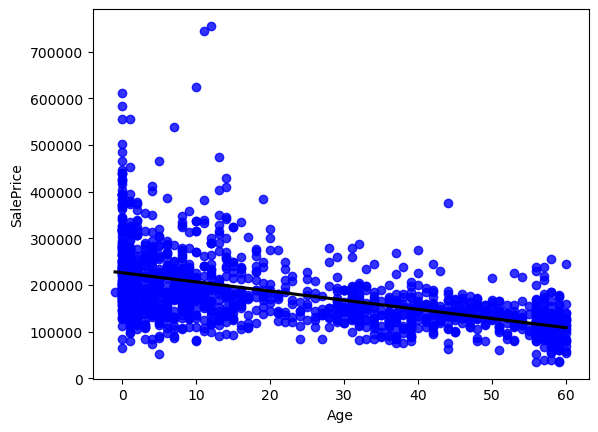

In [40]:
sns.regplot(
    data=df,
    x='Age',
    y='SalePrice',
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'black'},
    ci=None
)

Como conclusão, criando a variável Age reduzimos a quantidade de variáveis e adicionamos a lógica: casas mais novas tendem a ser mais caras.

### 5.6 OpenPorchSF

Existem 4 variáveis relacionadas a varanda: OpenPorchSF, EnclosedPorch, 3SsnPorch e ScreenPorch. Seguindo o README em data, todas essas variáveis dizem respeito a área da varanda em pés quadrados. Assim, podemos consolidá-las para verificar se existe melhora na correlação com o target SalePrice.

$$
    \text{TotalPorch} = \text{OpenPorchSF} + \text{EnclosedPorch} + \text{3SsnPorch} + \text{ScreenPorch}
$$



In [41]:
df['TotalPorch'] = (
    df['OpenPorchSF'] 
    + df['EnclosedPorch']
    + df['3SsnPorch']
    + df['ScreenPorch']
)

In [42]:
df[['TotalPorch', 'SalePrice']].corr()

,TotalPorch,SalePrice
TotalPorch,1.000000,0.195739
SalePrice,0.195739,1.000000


A correlação cai drasticamente pois, anteriormente OpenPorchSF tinha 0.39 de correlação, enquanto TotalPorch tem apenas 0.19.

### 5.7 LotFrontage

Vamos analisar agora os metros lineares de rua conectados ao lote. Para isso, vamos completar os valores ausentes utilizando a hipótese de que eles podem ser preenchidos pela média do bairro:


In [43]:
df.groupby('Neighborhood')['LotFrontage'].median().sort_values()

Neighborhood
BrDale     21.0
MeadowV    21.0
NPkVill    24.0
Blueste    24.0
Blmngtn    43.0
BrkSide    52.0
IDOTRR     60.0
OldTown    60.0
SWISU      60.0
StoneBr    61.5
Gilbert    65.0
Edwards    65.5
SawyerW    66.5
Veenker    68.0
CollgCr    70.0
Sawyer     71.0
NAmes      73.0
Mitchel    73.0
Somerst    73.5
Crawfor    74.0
ClearCr    80.0
NWAmes     80.0
Timber     85.0
NridgHt    88.5
NoRidge    91.0
Name: LotFrontage, dtype: float64

<Axes: xlabel='LotFrontage', ylabel='SalePrice'>

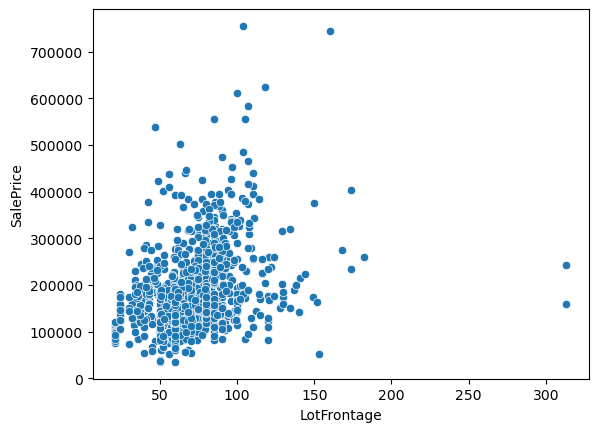

In [44]:
sns.scatterplot(x='LotFrontage', y='SalePrice', data=df)

## 6. Análise da relação entre variáveis categóricas e o target

Para analisarmos a relação entre as variáveis categóricas e o target, primeiro precisamos descobrir quem são e, feito isso, determinar de qual tipo: ordinal, nominal ou binárias.

In [45]:
cat_cols = list(df.select_dtypes(include=["object", "category"]).columns)

for col in cat_cols:
    print(col, df[col].nunique())

MSZoning 5
Street 2
Alley 2
LotShape 4
LandContour 4
Utilities 2
LotConfig 5
LandSlope 3
Neighborhood 25
Condition1 9
Condition2 8
BldgType 5
HouseStyle 8
RoofStyle 6
RoofMatl 8
Exterior1st 15
Exterior2nd 16
MasVnrType 3
ExterQual 4
ExterCond 5
Foundation 6
BsmtQual 4
BsmtCond 4
BsmtExposure 4
BsmtFinType1 6
BsmtFinType2 6
Heating 6
HeatingQC 5
CentralAir 2
Electrical 5
KitchenQual 4
Functional 7
FireplaceQu 5
GarageType 6
GarageFinish 3
GarageQual 5
GarageCond 5
PavedDrive 3
PoolQC 3
Fence 4
MiscFeature 4
SaleType 9
SaleCondition 6


In [46]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print()

MSZoning
['RL' 'RM' 'C (all)' 'FV' 'RH']

Street
['Pave' 'Grvl']

Alley
[nan 'Grvl' 'Pave']

LotShape
['Reg' 'IR1' 'IR2' 'IR3']

LandContour
['Lvl' 'Bnk' 'Low' 'HLS']

Utilities
['AllPub' 'NoSeWa']

LotConfig
['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']

LandSlope
['Gtl' 'Mod' 'Sev']

Neighborhood
['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']

Condition1
['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']

Condition2
['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']

BldgType
['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']

HouseStyle
['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']

RoofStyle
['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']

RoofMatl
['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']

Exterior1st
['Vin

## 6.1 Valores ausentes

As variáveis categoricas do dataset possuem uma grande quantidade de valores ausentes. Esses valores ausentes, muitas vezes, significam a ausência de determinada característica no imóvel, por exemplo:

In [47]:
missing_df = pd.DataFrame({
    'MissingCount': df.isnull().sum(),
    'MissingPercent': df.isnull().mean() * 100
})

missing_df = missing_df[missing_df['MissingCount'] > 0]
missing_df = missing_df.sort_values(by='MissingPercent', ascending=False)

print(missing_df)

              MissingCount  MissingPercent
PoolQC                1453       99.520548
MiscFeature           1406       96.301370
Alley                 1369       93.767123
Fence                 1179       80.753425
MasVnrType             872       59.726027
FireplaceQu            690       47.260274
LotFrontage            259       17.739726
GarageType              81        5.547945
GarageYrBlt             81        5.547945
GarageFinish            81        5.547945
GarageQual              81        5.547945
GarageCond              81        5.547945
BsmtExposure            38        2.602740
BsmtFinType2            38        2.602740
BsmtQual                37        2.534247
BsmtCond                37        2.534247
BsmtFinType1            37        2.534247
MasVnrArea               8        0.547945
Electrical               1        0.068493


| Variável | Como tratar missing values |
|----------|----------------------------|
| PoolQC | A grande quanidade de dados ausentes representa casas que não possuem piscina, substituir por "None"|
| MiscFeature | A residência não possui características não explicadas pelas outras variáveis, substituir por "None"|
| Alley | A residência não possui acesso a beco, substituir por "None" | 
| Fence | A residência não possui cercas, substituir por "None" |
| MasVnrType | A residência não possui revestimento de alvenaria, substituir por "None" | 
| FireplaceQu | A residência não possui lareira, substituir por "None" |
| LotFrontage | Não há informação do comprimento da rua conectada ao lote; pode ser estimado pela mediana do bairro (Neighborhood) |
| GarageType | A residência não possui garagem, substituir por "None"|
| GarageYrBlt | Não há informação sobre data de construção da garagem, substituir pelo mesmo ano de criação da casa (YearBuilt)| 
| GarageFinish | A residência não possui garagem, substituir por "None"| 
|GarageQual| A residência não possui garagem, substituir por "None"| 
|BsmtExposure| A residência não possui porão, substituir por "None"|
|BsmtFinType1| A residência não possui acabamento no porão, substituir por "None"|
|BsmtFinType2| A residência não possui segundo tipo de acabamento no porão, substituir por "None"|
|BsmtQual| A residência não possui porão, substituir por "None"|
|BsmtCond | A residência não possui porão, substituir por "None"| 
| BsmntFinType1 | A residência não possui acabamento principal no porão, substituir por "None"|
|MasVnrArea| Se MasVnrType = None, então MasVnrArea = 0|
| Electrical | Poucos valores faltantes, substituir pela moda| 


In [48]:
cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'MasVnrType', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'BsmtQual', 'BsmtCond'
]

for col in cols_none:
    print(f'\n{col}')
    print(df[col].value_counts(dropna=False))


PoolQC
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

MiscFeature
MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

Alley
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Fence
Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

MasVnrType
MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

FireplaceQu
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

GarageType
GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

GarageFinish
GarageFinish
Unf    605
RFn    422
Fin    352
NaN     81
Name: count, dtype: int64

GarageQual
GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

BsmtExpos


--- PoolQC ---
Value counts (incluindo NaN):
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

After fill with 'None':
PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64


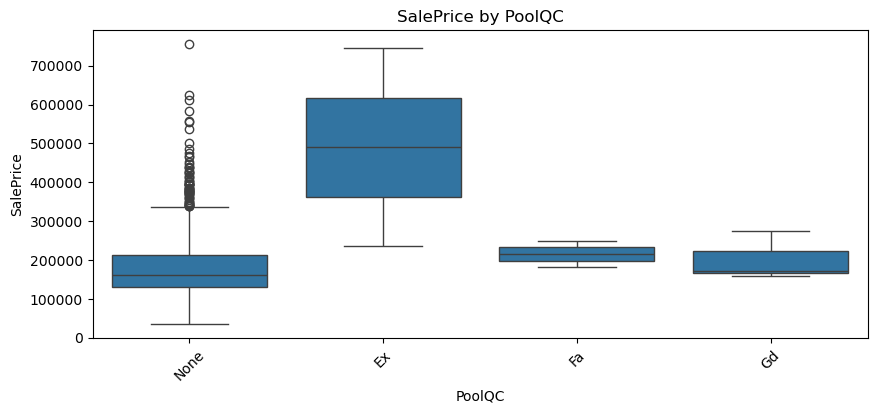


Mean SalePrice by category:
PoolQC
Ex      490000.000000
Fa      215500.000000
Gd      201990.000000
None    180404.663455
Name: SalePrice, dtype: float64
--------------------------------------------------

--- MiscFeature ---
Value counts (incluindo NaN):
MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64

After fill with 'None':
MiscFeature
None    1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64


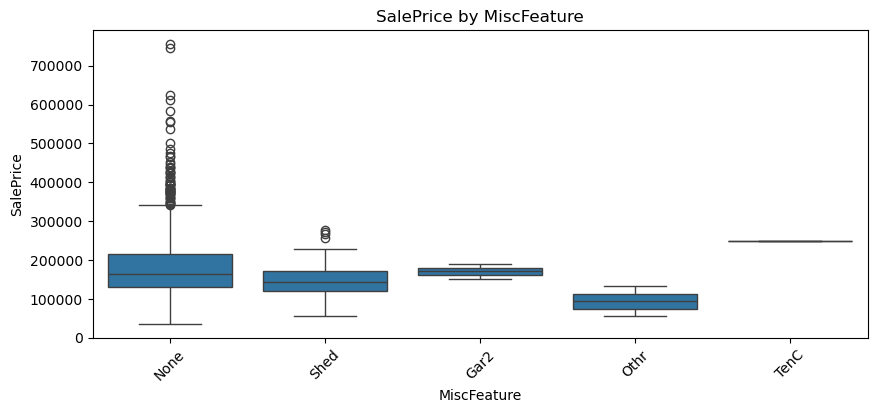


Mean SalePrice by category:
MiscFeature
TenC    250000.000000
None    182046.410384
Gar2    170750.000000
Shed    151187.612245
Othr     94000.000000
Name: SalePrice, dtype: float64
--------------------------------------------------

--- Alley ---
Value counts (incluindo NaN):
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

After fill with 'None':
Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64


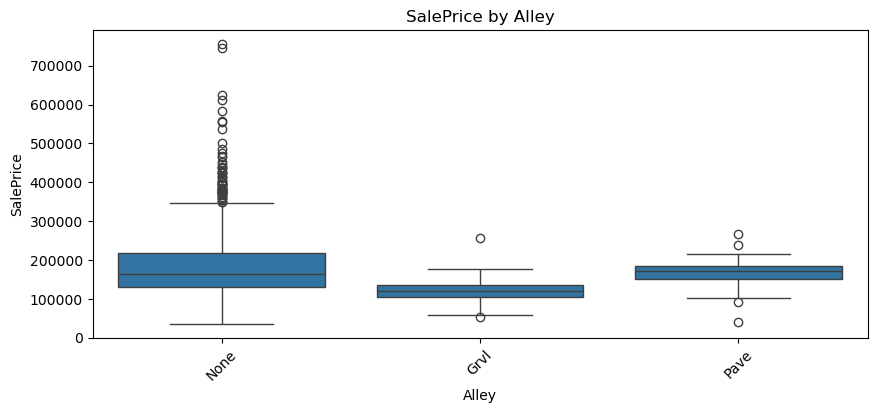


Mean SalePrice by category:
Alley
None    183452.131483
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64
--------------------------------------------------

--- Fence ---
Value counts (incluindo NaN):
Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64

After fill with 'None':
Fence
None     1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64


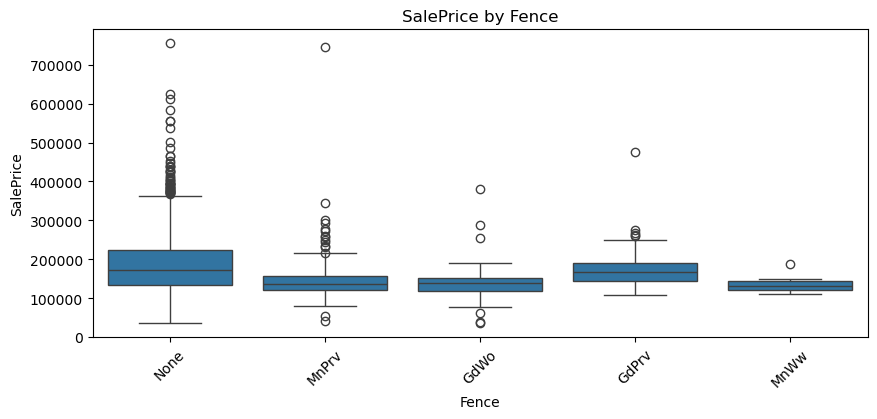


Mean SalePrice by category:
Fence
None     187596.837998
GdPrv    178927.457627
MnPrv    148751.089172
GdWo     140379.314815
MnWw     134286.363636
Name: SalePrice, dtype: float64
--------------------------------------------------

--- MasVnrType ---
Value counts (incluindo NaN):
MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

After fill with 'None':
MasVnrType
None       872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64


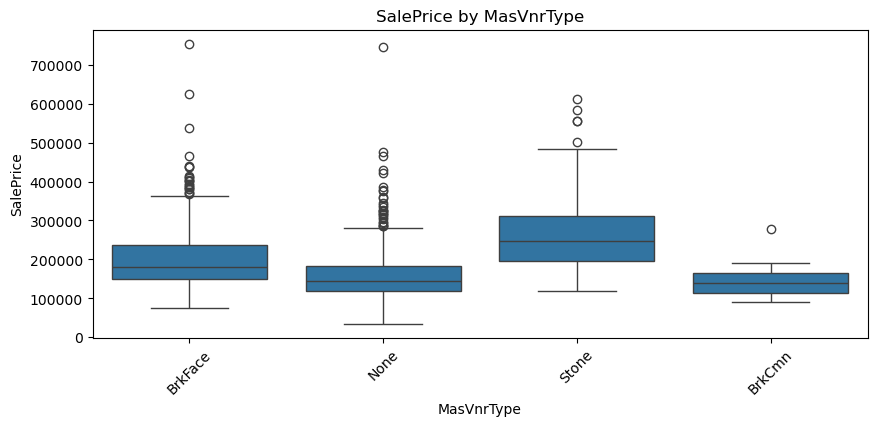


Mean SalePrice by category:
MasVnrType
Stone      265583.625000
BrkFace    204691.871910
None       156958.243119
BrkCmn     146318.066667
Name: SalePrice, dtype: float64
--------------------------------------------------

--- FireplaceQu ---
Value counts (incluindo NaN):
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

After fill with 'None':
FireplaceQu
None    690
Gd      380
TA      313
Fa       33
Ex       24
Po       20
Name: count, dtype: int64


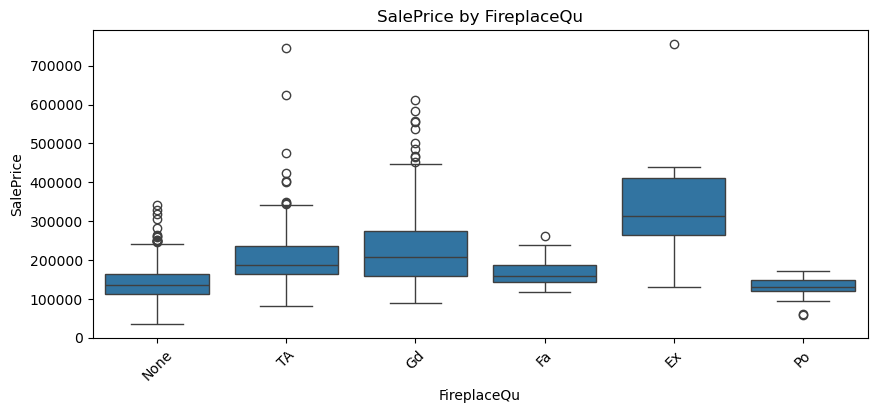


Mean SalePrice by category:
FireplaceQu
Ex      337712.500000
Gd      226351.415789
TA      205723.488818
Fa      167298.484848
None    141331.482609
Po      129764.150000
Name: SalePrice, dtype: float64
--------------------------------------------------

--- GarageType ---
Value counts (incluindo NaN):
GarageType
Attchd     870
Detchd     387
BuiltIn     88
NaN         81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

After fill with 'None':
GarageType
Attchd     870
Detchd     387
BuiltIn     88
None        81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64


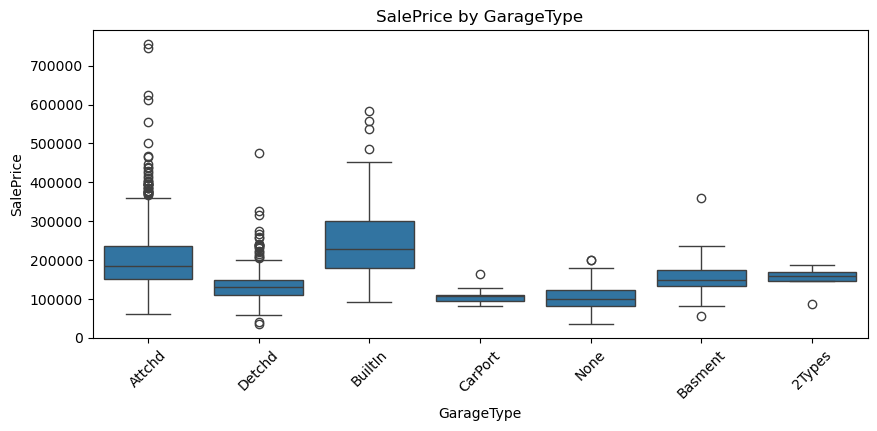


Mean SalePrice by category:
GarageType
BuiltIn    254751.738636
Attchd     202892.656322
Basment    160570.684211
2Types     151283.333333
Detchd     134091.162791
CarPort    109962.111111
None       103317.283951
Name: SalePrice, dtype: float64
--------------------------------------------------

--- GarageFinish ---
Value counts (incluindo NaN):
GarageFinish
Unf    605
RFn    422
Fin    352
NaN     81
Name: count, dtype: int64

After fill with 'None':
GarageFinish
Unf     605
RFn     422
Fin     352
None     81
Name: count, dtype: int64


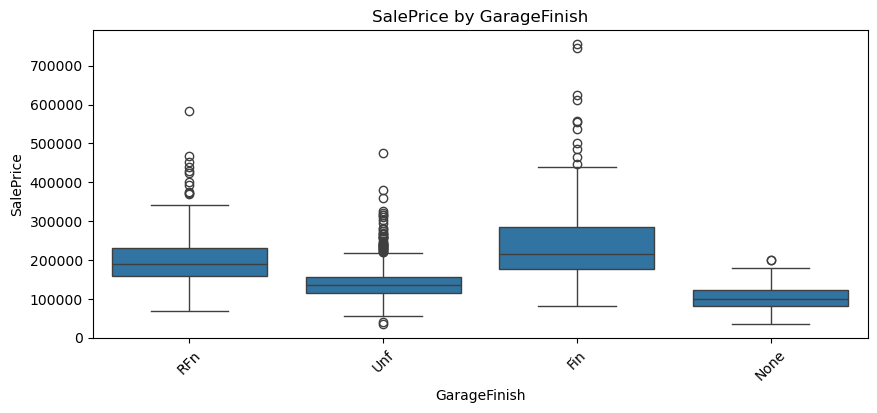


Mean SalePrice by category:
GarageFinish
Fin     240052.690341
RFn     202068.869668
Unf     142156.423140
None    103317.283951
Name: SalePrice, dtype: float64
--------------------------------------------------

--- GarageQual ---
Value counts (incluindo NaN):
GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

After fill with 'None':
GarageQual
TA      1311
None      81
Fa        48
Gd        14
Ex         3
Po         3
Name: count, dtype: int64


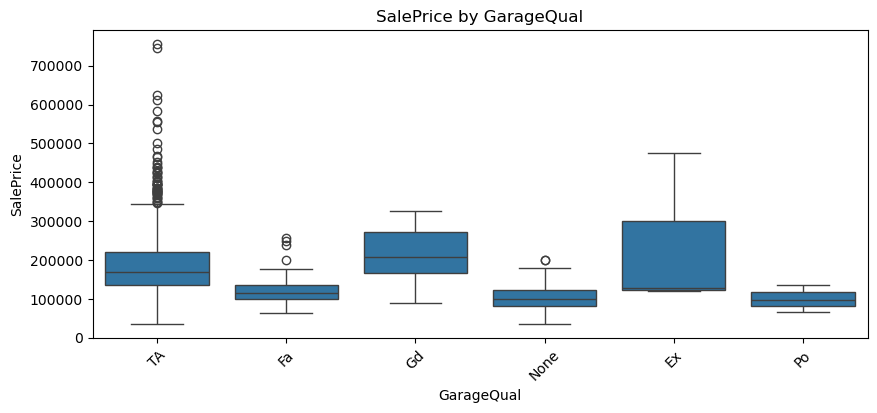


Mean SalePrice by category:
GarageQual
Ex      241000.000000
Gd      215860.714286
TA      187489.836003
Fa      123573.354167
None    103317.283951
Po      100166.666667
Name: SalePrice, dtype: float64
--------------------------------------------------

--- BsmtExposure ---
Value counts (incluindo NaN):
BsmtExposure
No     953
Av     221
Gd     134
Mn     114
NaN     38
Name: count, dtype: int64

After fill with 'None':
BsmtExposure
No      953
Av      221
Gd      134
Mn      114
None     38
Name: count, dtype: int64


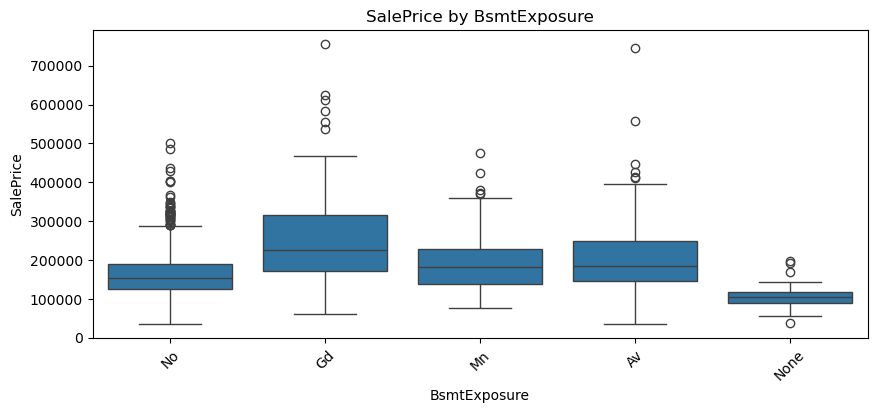


Mean SalePrice by category:
BsmtExposure
Gd      257689.805970
Av      206643.420814
Mn      192789.657895
No      165652.295908
None    107938.342105
Name: SalePrice, dtype: float64
--------------------------------------------------

--- BsmtFinType1 ---
Value counts (incluindo NaN):
BsmtFinType1
Unf    430
GLQ    418
ALQ    220
BLQ    148
Rec    133
LwQ     74
NaN     37
Name: count, dtype: int64

After fill with 'None':
BsmtFinType1
Unf     430
GLQ     418
ALQ     220
BLQ     148
Rec     133
LwQ      74
None     37
Name: count, dtype: int64


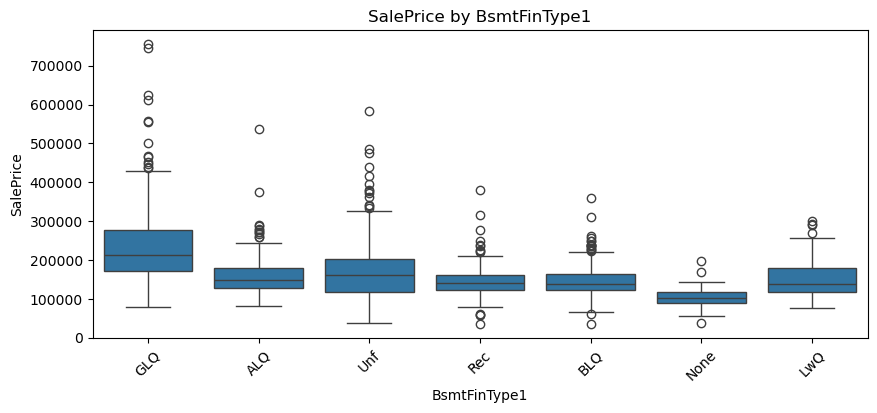


Mean SalePrice by category:
BsmtFinType1
GLQ     235413.720096
Unf     170670.576744
ALQ     161573.068182
LwQ     151852.702703
BLQ     149493.655405
Rec     146889.248120
None    105652.891892
Name: SalePrice, dtype: float64
--------------------------------------------------

--- BsmtFinType2 ---
Value counts (incluindo NaN):
BsmtFinType2
Unf    1256
Rec      54
LwQ      46
NaN      38
BLQ      33
ALQ      19
GLQ      14
Name: count, dtype: int64

After fill with 'None':
BsmtFinType2
Unf     1256
Rec       54
LwQ       46
None      38
BLQ       33
ALQ       19
GLQ       14
Name: count, dtype: int64


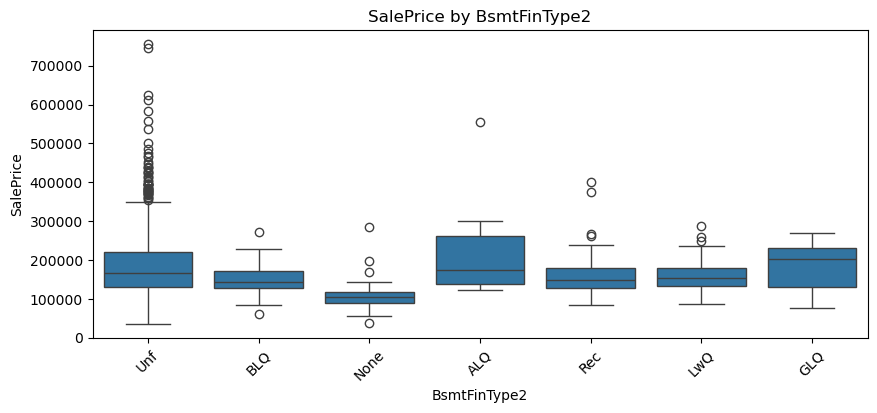


Mean SalePrice by category:
BsmtFinType2
ALQ     209942.105263
Unf     184694.690287
GLQ     180982.142857
Rec     164917.129630
LwQ     164364.130435
BLQ     151101.000000
None    110346.236842
Name: SalePrice, dtype: float64
--------------------------------------------------

--- BsmtQual ---
Value counts (incluindo NaN):
BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64

After fill with 'None':
BsmtQual
TA      649
Gd      618
Ex      121
None     37
Fa       35
Name: count, dtype: int64


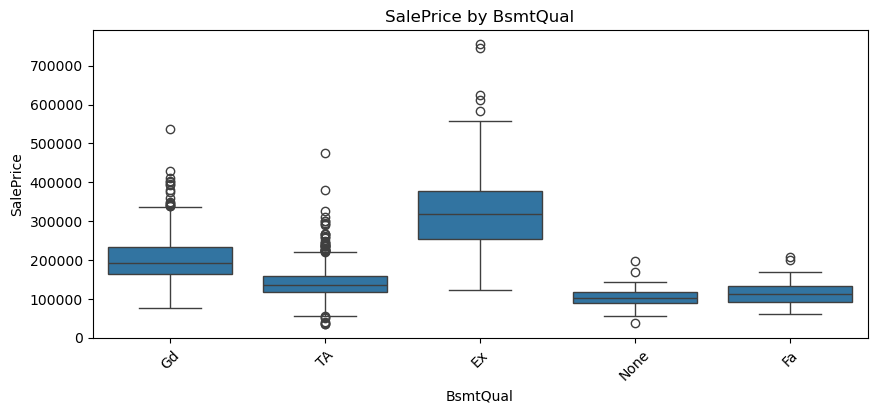


Mean SalePrice by category:
BsmtQual
Ex      327041.041322
Gd      202688.478964
TA      140759.818182
Fa      115692.028571
None    105652.891892
Name: SalePrice, dtype: float64
--------------------------------------------------

--- BsmtCond ---
Value counts (incluindo NaN):
BsmtCond
TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: count, dtype: int64

After fill with 'None':
BsmtCond
TA      1311
Gd        65
Fa        45
None      37
Po         2
Name: count, dtype: int64


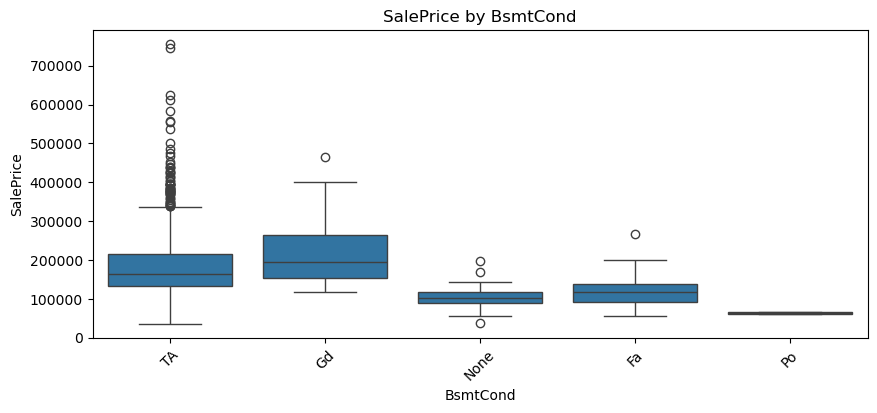


Mean SalePrice by category:
BsmtCond
Gd      213599.907692
TA      183632.620900
Fa      121809.533333
None    105652.891892
Po       64000.000000
Name: SalePrice, dtype: float64
--------------------------------------------------


In [49]:
for col in cols_none:

    print(f"\n--- {col} ---")
    print("Value counts (incluindo NaN):")
    print(df[col].value_counts(dropna=False))
    
    df[col] = df[col].fillna('None')

    print("\nAfter fill with 'None':")
    print(df[col].value_counts())
    
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=col, y='SalePrice', data=df)
    plt.title(f'SalePrice by {col}')
    plt.xticks(rotation=45)
    plt.show()

    print("\nMean SalePrice by category:")
    print(df.groupby(col)['SalePrice'].mean().sort_values(ascending=False))
    print("-" * 50)

Em praticamente todas as colunas, a categoria 'None' (que originalmente era 'NaN') aparece com preço mais baixo. Isso é esperado, pois indica ausência de um atributo que normalmente agrega valor: piscina, garagem, lareira, acabamento, etc.

Isso acontece com exceção da variável **Aley**, as casas com 'None' tem preço médio maior do que as que possuem acesso por rua de cascalho (Grvl) ou pavimentada (Pave). Isso pode indicar que casas com acesso direto por rua (mesmo que não tenham "alley") são mais valorizadas, ou que bairros mais caros simplesmente não possuem esse tipo de acesso.

### 6.2 PoolQC

Apenas 7 casas possuem piscina (3 Gd, 2 Ex, 2 Fa).

Apesar de casas com piscina possuírem valor maior que a média, são muito raras no dataset. Também existem casas sem piscina com valores muito altos mas, em média, são mais baratas. Por ser uma variável rara, iremos excluir as categóricas e em feature engineering transformar em uma classificação binária.

### 6.3 MiscFeature 

A grande maioria das casas não possuem características que não podem ser descritas pelas outras variáveis (MiscFeature). Existe somente uma casa que possui quadra de tênis.

Em feature engineering, vou verificar se transformar MiscFeature em variável binária favore os modelos.

### 6.5 Neighborhood

Agora, vamos avaliar: o bairro impacta SalePrice? quanto ele impacta? ele domina outras variáveis?

Para responder essas perguntas, vamos começar explorando o preço por bairro:

### 6.6 Fence

Existem menos casas com cerca do que sem cerca. Além disso, a presença da cerca não causa um grande impacto no valor final do imóvel. Assim, essa variável será descartada.

### 6.7 MasVnrType

A presença de revestimento de alvenaria Stone favore o preço final do imóvel, enquanto BrkCmn não. A ordem de relevância é:

$$
    \text{Stone} > \text{BrkFace} > \text{None} > \text{BrkCmnn}
$$

Assim, podemos avaliar a possibilidade de criar uma variável binária $is_stone$ ou categorizar por níveis, caso essa variável seja detectada como relavante.


### 6.8 FireplaceQu

Casas com lareira classificadas como Ex possuem maior preço, mas são apenas 24 no dataset. As categorias Gd, Ta e Fa mostram queda gradativa, enquanto None (sem lareira) possui o menor preço. A qualidade da lareira aparenta ser um forte preditor, mesmo lareiras de qualidade regular ainda têm preço maior que casas sem lareira.

### 6.9 GarageType, GarageFinish e GarageQual

Para GarageType: BuiltIn (garagem embutida) tem o maior preço, seguida por Attch. Detchd e CarPort.

$$
    \text{BuiltIn} > \text{Attch} > \text{Detchd} > \text{CarPort}
$$

Para GarageFinish: 

$$
    \text{Fin} > \text{RFn} > \text{Unf} > \text{None}
$$

Para GarageQual: Ex e Gd têm preços altos, TA intermediário, Fa e Po baixos, com None (sem garagem) o mais baixo.

A presença de garagem impacta fortemente no preço, como vimos anteriormente. Assim, podemos usar essas variáveis combinadas ou criar uma pontuação única por meio de uma média ponderada.

### 6.10 BsmtExposure, BsmtFinType1/2, BsmtQual, BsmtCond

Para BsmtExposure:

$$
    \text{Gd} > \text{Av} > \text{Mn} > \text{Po} > \text{None}
$$

Para BsmtFinType1:

$$
    \text{GLQ} > \text{Unf} > \text{None}
$$

Para BsmtQual: Ex tem preço muito superior a Gd e Ta, o que mostra que a qualidade estrutural do porão é extremamente valorizada.

Para BsmtCond:

$$
    \text{Gd} > \text{Av} > \text{Mn} > \text{Po} > \text{None}
$$


O porão é uma característica importante. A qualidade e o tipo de acabamento parecem ser os mais influentes.


### 7. Neighborhood

Inicialmente, vamos apenas calcular qual bairro possui a maior média de valores para casas e qual possui a menor:

In [50]:
neigh_stats = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'count'])

neigh_stats = neigh_stats.sort_values(by='mean', ascending=False)

print(neigh_stats)

                       mean    median  count
Neighborhood                                
NoRidge       335295.317073  301500.0     41
NridgHt       316270.623377  315000.0     77
StoneBr       310499.000000  278000.0     25
Timber        242247.447368  228475.0     38
Veenker       238772.727273  218000.0     11
Somerst       225379.837209  225500.0     86
ClearCr       212565.428571  200250.0     28
Crawfor       210624.725490  200624.0     51
CollgCr       197965.773333  197200.0    150
Blmngtn       194870.882353  191000.0     17
Gilbert       192854.506329  181000.0     79
NWAmes        189050.068493  182900.0     73
SawyerW       186555.796610  179900.0     59
Mitchel       156270.122449  153500.0     49
NAmes         145847.080000  140000.0    225
NPkVill       142694.444444  146000.0      9
SWISU         142591.360000  139500.0     25
Blueste       137500.000000  137500.0      2
Sawyer        136793.135135  135000.0     74
OldTown       128225.300885  119000.0    113
Edwards   

Agora, olhamos a maior média:

In [51]:
bairro_mais_caro = neigh_stats.index[0]
valor_mais_caro = neigh_stats.iloc[0]['mean']

print(bairro_mais_caro, valor_mais_caro)

NoRidge 335295.31707317074


O bairro mais caro é o de NoRidge.

In [52]:
bairro_mais_barato = neigh_stats.index[-1]
valor_mais_barato = neigh_stats.iloc[-1]['mean']

print(bairro_mais_barato, valor_mais_barato)

MeadowV 98576.4705882353


O bairro mais barato é o de MeadowV.

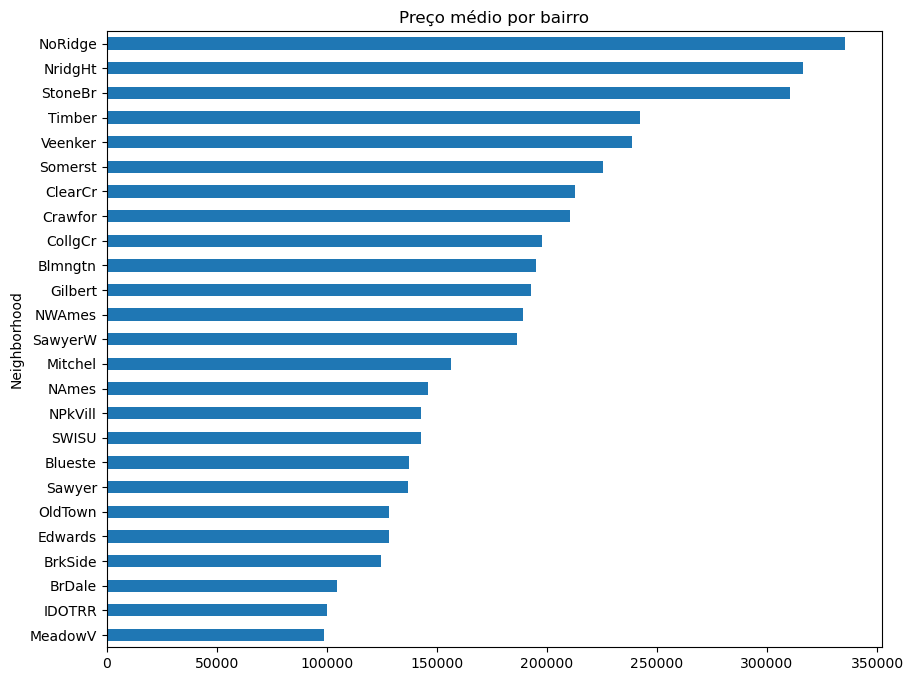

In [53]:

neigh_stats['mean'].sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Preço médio por bairro')
plt.show()

Para uma análise completa, é necessário avalar se o bairro possui consistência de preços ou está sendo tomado por outliers, se as casas são novas e se possuem acabamento de qualidade. Para essa avaliação, vamos montar um score:

$$
    \text{Score} = \frac{5}{10} \times \text{SalePrice} + \frac{3}{10} \times \text{OverallQual mean} + \frac{2}{10} \text{YearBuilt},
$$

com todas as variáveis normalizadas.


In [54]:
neigh = df.groupby("Neighborhood").agg({
    "SalePrice": "mean",
    "OverallQual": ["mean", "std"], 
    "YearBuilt": "mean"
})

In [55]:
neigh.columns = ['SalePrice', 'OverallQual_mean', 'OverallQual_std', 'YearBuilt']

In [56]:
neigh = neigh.rename(columns={
    "OverallQual_mean": "Qual_mean",
    "OverallQual_std": "Qual_std"
})

for col in ["SalePrice", "Qual_mean", "YearBuilt"]:
    neigh[col + "_z"] = (neigh[col] - neigh[col].mean()) / neigh[col].std()

In [57]:
neigh["Score"] = (
    0.5 * neigh["SalePrice_z"] +
    0.3 * neigh["Qual_mean_z"] +
    0.2 * neigh["YearBuilt_z"]
)

In [58]:
resultado = neigh.sort_values(by="Score", ascending=False)

resultado

,SalePrice,Qual_mean,Qual_std,YearBuilt,SalePrice_z,Qual_mean_z,YearBuilt_z,Score
Neighborhood,,,,,,,,
NridgHt,316270.623377,8.259740,0.992108,2005.675325,1.982846,1.969981,1.248076,1.832032
NoRidge,335295.317073,7.926829,0.848241,1995.439024,2.267966,1.653938,0.858118,1.801788
StoneBr,310499.000000,8.160000,0.687992,1998.480000,1.896347,1.875295,0.973966,1.705555
Somerst,225379.837209,7.337209,0.806014,2004.988372,0.620680,1.094194,1.221906,0.882979
Timber,242247.447368,7.157895,1.197437,1992.842105,0.873472,0.923965,0.759186,0.865763
Veenker,238772.727273,6.727273,1.348400,1982.363636,0.821397,0.515162,0.360002,0.637248
Blmngtn,194870.882353,7.176471,0.392953,2005.235294,0.163447,0.941600,1.231313,0.610466
CollgCr,197965.773333,6.640000,1.038067,1997.886667,0.209830,0.432312,0.951362,0.424881
Gilbert,192854.506329,6.556962,0.780316,1998.253165,0.133228,0.353481,0.965324,0.365723


Assim, os top10 melhores bairros são:

- NridgHt
- NoRidge
- StoneBr
- Somerst
- Timber
- Veenker
- Blmngtn
- CollgCr
- Gilbert
- SawyerW

Os top10 piores bairros são:

- Blueste
- NAmes
- BrDale
- Sawyer
- Edwards
- SWISU
- OldTown
- BrkSide
- MeadowV
- IDOTRR

### 8. KitchenQual e KitchenAbvGr

<Axes: xlabel='KitchenQual', ylabel='SalePrice'>

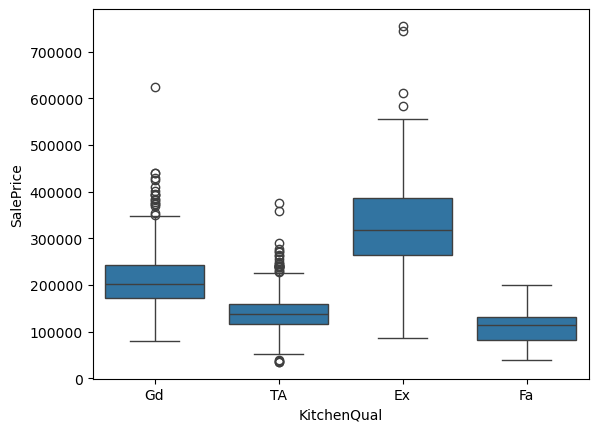

In [59]:
df['KitchenQual'] = df['KitchenQual'].fillna('None')

sns.boxplot(data=df, x='KitchenQual', y='SalePrice')

In [60]:
df.groupby('KitchenQual')['SalePrice'].mean().sort_values(ascending=False)

KitchenQual
Ex    328554.670000
Gd    212116.023891
TA    139962.511565
Fa    105565.205128
Name: SalePrice, dtype: float64

In [61]:
df.groupby('KitchenQual')['OverallQual'].mean().sort_values(ascending=False)

KitchenQual
Ex    8.270000
Gd    6.790102
TA    5.338776
Fa    4.487179
Name: OverallQual, dtype: float64

Quanto melhor a qualidade da cozinha, maior o preço médio. A diferença entre Ex e Fa é de mais de 220k, mostrando que a cozinha é um dos cômodos de maior impacto no valor do imóvel. A média de OverallQual segue a mesma ordenação, isso sugere que cozinhas de alta qualidade costumam estar em imóveis com acabamento geral superior, mas também que a própria cozinha é um dos componentes mais importantes na avalição da qualidade total.

<Axes: xlabel='KitchenAbvGr', ylabel='SalePrice'>

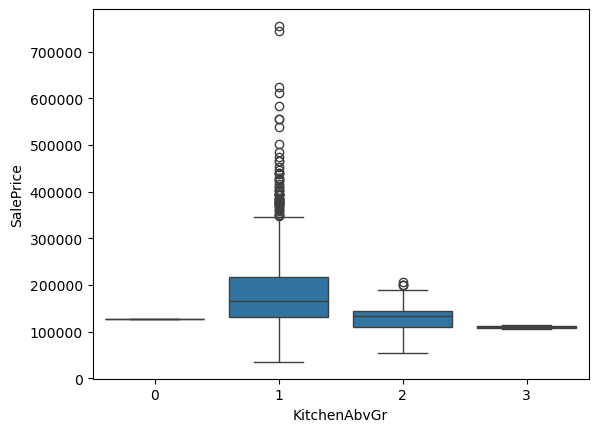

In [62]:
df['KitchenAbvGr'] = df['KitchenAbvGr'].fillna('None')

sns.boxplot(data=df, x='KitchenAbvGr', y='SalePrice')

In [63]:
df.groupby('KitchenAbvGr')['SalePrice'].mean().sort_values(ascending=False)

KitchenAbvGr
1    183388.790230
2    131096.153846
0    127500.000000
3    109500.000000
Name: SalePrice, dtype: float64

In [64]:
pd.crosstab(df['KitchenAbvGr'], df['KitchenQual'], margins=True)

KitchenQual,Ex,Fa,Gd,TA,All
KitchenAbvGr,,,,,
0,0,0,0,1,1
1,100,34,583,675,1392
2,0,5,3,57,65
3,0,0,0,2,2
All,100,39,586,735,1460


No dataset, quanto maior a quantidade de cozinhas, menores são as notas de KitchenQual. Assim, como KitchenQual é uma variável muito importante para o preço final, casas com mais de 1 cozinha tendem a perder valor.

### 9. Foundation

In [65]:
df['Foundation'].value_counts()

Foundation
PConc     647
CBlock    634
BrkTil    146
Slab       24
Stone       6
Wood        3
Name: count, dtype: int64

<Axes: xlabel='Foundation', ylabel='SalePrice'>

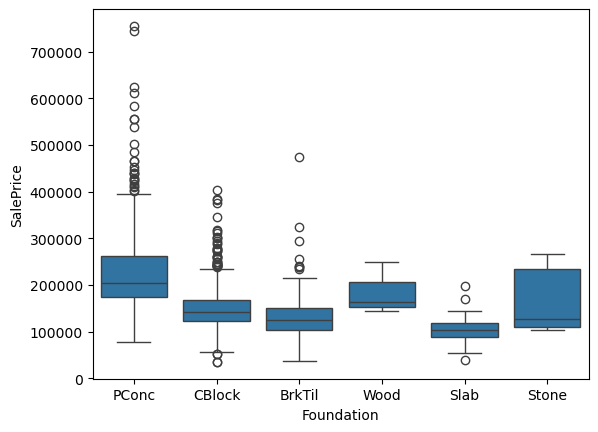

In [66]:
df['Foundation'] = df['Foundation'].fillna('None')

sns.boxplot(data=df, x='Foundation', y='SalePrice')

In [67]:
df.groupby('Foundation')['SalePrice'].mean().sort_values(ascending=False)

Foundation
PConc     225230.442040
Wood      185666.666667
Stone     165959.166667
CBlock    149805.714511
BrkTil    132291.075342
Slab      107365.625000
Name: SalePrice, dtype: float64

In [68]:
df.groupby('Foundation')['OverallQual'].mean().sort_values(ascending=False)

Foundation
PConc     6.979907
Wood      6.666667
Stone     5.666667
BrkTil    5.445205
CBlock    5.421136
Slab      4.291667
Name: OverallQual, dtype: float64

As fundações de concreto (PConc e CBlock) somam mais de 1200 observações, representando grande maioria do dataset. Dentre elas, a função PConc está fortemente ligada a casas de maior valor e qualidade. Wood, Stone e Slab tem baixa representatividade. Wood e Stone podem indiicar construções históricas ou de nicho, enquanto Slab é típica de casas mais econômicas. 

Como existem categorias poucas representativas, pode ser adequado classificar Wood, Stone e Slab como "outras".

Para verificar como foundation se relaciona com a idade da casa:

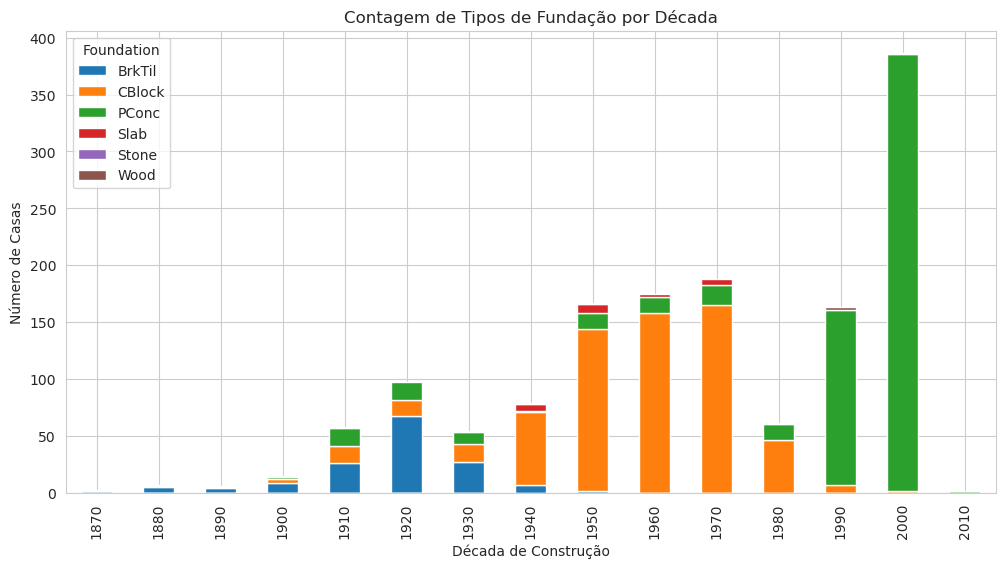

In [69]:
sns.set_style("whitegrid")

df['Decade'] = (df['YearBuilt'] // 10) * 10
decade_foundation = df.groupby(['Decade', 'Foundation'])['SalePrice'].mean().unstack()

foundation_by_decade = pd.crosstab(df['Decade'], df['Foundation'])
foundation_by_decade.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Contagem de Tipos de Fundação por Década')
plt.xlabel('Década de Construção')
plt.ylabel('Número de Casas')
plt.legend(title='Foundation')
plt.show()

Casas mais novas possuem fundação do tipo PConc e, como casas mais novas possuem preço mais elevado, PConc predomina entre as casas mais caras.